### Aside: *seeing* the standard error (CLT + the √N law)

Two simulations. **A1** re-draws the full dataset (bootstrap) and refits many times —
the spread of those refits *is* the SE, and the histogram *is* the sampling distribution.
**A2** shrinks the sample and watches the SE grow like 1/√n — the cancellation argument, visible.

In [29]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import config as C
from chicago_housing.data.load import load_training_data
from chicago_housing.data import clean
from chicago_housing.features import assemble
from chicago_housing.models import inference

# rows then columns (the separation we built)
df       = load_training_data(columns=C.analysis_columns())
sample   = clean.build_analytic_sample(df)     # scope + validity + log target
model_df = assemble.build_features(sample)     # + dist_to_loop_ft, school flag
model_df.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
scope_filter:         413,289 ->   33,106 rows
drop_non_market: 33,106 -> 30,693
  always (PTAX/family):   1,747
  below $10,000 floor:  0
  entity + nominal/low:   670
  land-trust/title kept (market price): 1,247
analytic sample:                30,693 rows


(30693, 43)

In [30]:
# build clean, aligned arrays ONCE — no NaNs, correct dtype
mask = model_df["char_bldg_sf"].notna() & model_df[C.TARGET].notna()
x = model_df.loc[mask, "char_bldg_sf"].to_numpy(float)
y = model_df.loc[mask, C.TARGET].to_numpy(float)
N = len(x)
print("clean N:", N, " any NaN:", np.isnan(x).any() or np.isnan(y).any())

clean N: 30691  any NaN: False


In [31]:
# Run the OLS with a single predictor: square footage
res1 = inference.fit_ols(model_df, C.TARGET, ["char_bldg_sf"])
print(res1.summary())

                            OLS Regression Results                            
Dep. Variable:         log_sale_price   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                 2.131e+04
Date:                Mon, 06 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:20:47   Log-Likelihood:                -29383.
No. Observations:               30691   AIC:                         5.877e+04
Df Residuals:                   30689   BIC:                         5.879e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           11.4926      0.009   1331.103   

slope estimate      : 7.853e-04
formula SE (OLS)     : 5.379e-06
bootstrap SD         : 7.975e-06   <- matches the formula SE
bootstrap mean       : 7.850e-04   <- sits on the estimate (unbiased)


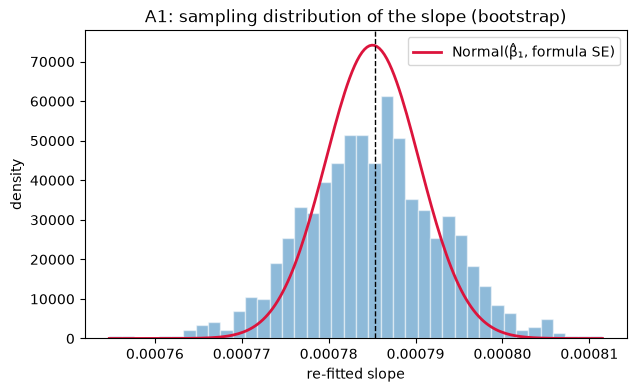

In [32]:
# Bootstrapping
rng = np.random.default_rng(0)

# clean, aligned arrays (mask out the handful of NaNs — see Step 0a: "0.000" ≠ zero)
#mask = model_df["char_bldg_sf"].notna() & model_df[C.TARGET].notna()
#x = model_df.loc[mask, "char_bldg_sf"].to_numpy(float)
#y = model_df.loc[mask, C.TARGET].to_numpy(float)
#N = len(x)
assert np.isfinite(x).all() and np.isfinite(y).all(), "NaNs leaked into x/y"

def slope(x, y):
    xc = x - x.mean()
    return (xc * (y - y.mean())).sum() / (xc**2).sum()
# Create a bootstrapped sample of B = 1000
# such that each sample is = len(x)
B = 1000
boot = np.array([slope(x[i], y[i]) for i in (rng.integers(0, N, N) for _ in range(B))])

formula_se = res1.bse["char_bldg_sf"]
print(f"slope estimate      : {res1.params['char_bldg_sf']:.3e}")
print(f"formula SE (OLS)     : {formula_se:.3e}")
print(f"bootstrap SD         : {boot.std(ddof=1):.3e}   <- matches the formula SE")
print(f"bootstrap mean       : {boot.mean():.3e}   <- sits on the estimate (unbiased)")

# the histogram IS the sampling distribution; overlay the normal CLT predicts
plt.figure(figsize=(7, 4))
plt.hist(boot, bins=40, density=True, alpha=0.5, edgecolor="white")
grid = np.linspace(boot.min(), boot.max(), 200)
normal = np.exp(-0.5*((grid-boot.mean())/formula_se)**2) / (formula_se*np.sqrt(2*np.pi))
plt.plot(grid, normal, "crimson", lw=2, label="Normal(β̂₁, formula SE)")
plt.axvline(res1.params["char_bldg_sf"], color="k", ls="--", lw=1)
plt.xlabel("re-fitted slope"); plt.ylabel("density")
plt.title("A1: sampling distribution of the slope (bootstrap)"); plt.legend()
plt.show()

In [33]:
rng = np.random.default_rng(0) # random number generator seeded with 0
print(rng)
for _ in range(B):
    rng.integers(0,N,N) # from the range [0,N)11

Generator(PCG64)


In [34]:
print("x NaNs:", np.isnan(x).sum(), " y NaNs:", np.isnan(y).sum(), " N:", N)
print("boot finite:", np.isfinite(boot).sum(), "of", len(boot))

x NaNs: 0  y NaNs: 0  N: 30691
boot finite: 1000 of 1000


In [35]:
print("sizes:", sizes)
print("emp_se:", emp_se)
print("k:", k, " x.var():", x.var(), " sigma:", sigma)

sizes: [500, 1000, 2000, 4000, 8000, 16000]
emp_se: [np.float64(5.710572899729262e-05), np.float64(4.067680776917946e-05), np.float64(3.366373208582475e-05), np.float64(2.084436532493216e-05), np.float64(1.3882058999330115e-05), np.float64(7.648844192612859e-06)]
k: 0.0009423664131508391  x.var(): 447392.671060809  sigma: 0.6303245635395218


In [ ]:
res1.scale

np.float64(0.39730905540128875)

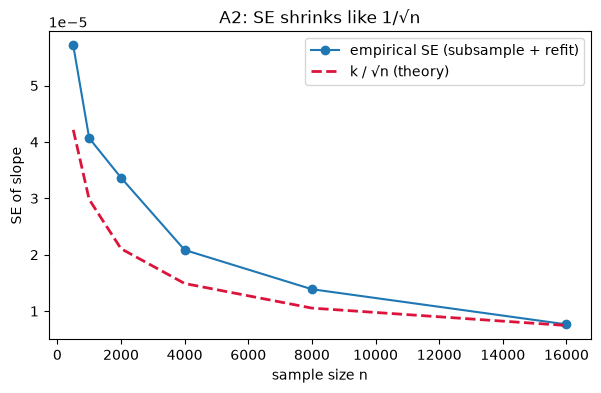

n=   500   empirical SE=5.711e-05   k/√n=4.214e-05
n=  1000   empirical SE=4.068e-05   k/√n=2.980e-05
n=  2000   empirical SE=3.366e-05   k/√n=2.107e-05
n=  4000   empirical SE=2.084e-05   k/√n=1.490e-05
n=  8000   empirical SE=1.388e-05   k/√n=1.054e-05
n= 16000   empirical SE=7.649e-06   k/√n=7.450e-06


In [36]:
sigma = np.sqrt(res1.scale)              # RSE (estimate of σ)
k = sigma / np.sqrt(x.var())             # SE(n) ≈ k / √n
sizes = [500, 1000, 2000, 4000, 8000, 16000]
reps = 200

emp_se = []
for n in sizes:
    slopes = np.empty(reps)
    for r in range(reps):
        idx = rng.choice(N, n, replace=False)   # a smaller "what if I only had n sales"
        slopes[r] = slope(x[idx], y[idx])
    emp_se.append(slopes.std(ddof=1))

plt.figure(figsize=(7, 4))
plt.plot(sizes, emp_se, "o-", label="empirical SE (subsample + refit)")
plt.plot(sizes, [k/np.sqrt(n) for n in sizes], "crimson", lw=2, ls="--", label="k / √n (theory)")
plt.xlabel("sample size n"); plt.ylabel("SE of slope")
plt.title("A2: SE shrinks like 1/√n"); plt.legend()
plt.show()

for n, se in zip(sizes, emp_se):
    print(f"n={n:6d}   empirical SE={se:.3e}   k/√n={k/np.sqrt(n):.3e}")

In [38]:
res_robust = inference.fit_ols(model_df, C.TARGET, ["char_bldg_sf"]).get_robustcov_results(cov_type="HC3")
print(res_robust.bse)   # expect ≈ the bootstrap SD, not the classical 5.4e-6

[1.22770770e-02 8.27939194e-06]


#### Fun Plots for Diagnosis

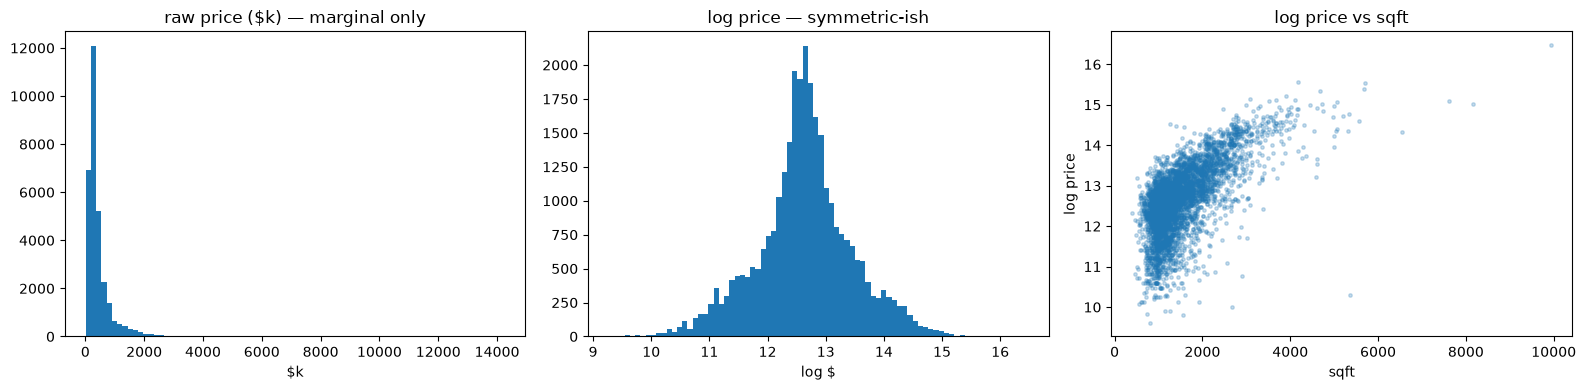

In [56]:
# Plot of just target and target with predictor
fitted_idx = res1.resid.index

sqft  = model_df.loc[fitted_idx, "char_bldg_sf"].to_numpy(float)
logp  = model_df.loc[fitted_idx, C.TARGET].to_numpy(float)
price = model_df.loc[fitted_idx, C.TARGET_RAW].to_numpy(float)
resid = res1.resid.to_numpy()

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# (1) y alone — marginal distribution; note the fat right tail, but NO x to spread against
ax[0].hist(price/1000, bins=80); ax[0].set_title("raw price ($k) — marginal only"); ax[0].set_xlabel("$k")
ax[1].hist(logp, bins=80);       ax[1].set_title("log price — symmetric-ish");      ax[1].set_xlabel("log $")
# (2) y vs sqft — the funnel begins to appear
s = np.random.default_rng(0).choice(len(sqft), min(5000, len(sqft)), replace=False)
ax[2].scatter(sqft[s], logp[s], s=6, alpha=0.25); ax[2].set_title("log price vs sqft"); ax[2].set_xlabel("sqft"); ax[2].set_ylabel("log price")
plt.tight_layout(); plt.show()

In [57]:
print(len(sqft), len(logp), len(resid))

30691 30691 30691


In [58]:
# Key intuition to understand heteroskedasticity
resid = res1.resid.to_numpy()   # residuals from your Step-1 fit (log price ~ sqft)
d = pd.DataFrame({
    "sqft": sqft,
    "logp": logp,
    "resid": resid
}, index=fitted_idx)
d["sqft_decile"] = pd.qcut(d["sqft"], 10, labels=False)

tbl = d.groupby("sqft_decile").agg(
    sqft_lo   = ("sqft", "min"),
    sqft_hi   = ("sqft", "max"),
    n         = ("resid", "size"),
    resid_sd  = ("resid", "std"),      # <- THE column: does scatter grow across deciles?
    logp_sd   = ("logp", "std"),
)
tbl["resid_sd_vs_decile0"] = tbl["resid_sd"] / tbl["resid_sd"].iloc[0]
tbl.round(3)

,sqft_lo,sqft_hi,n,resid_sd,logp_sd,resid_sd_vs_decile0
sqft_decile,,,,,,
0,400.0,896.0,3078,0.695,0.700,1.000
1,897.0,992.0,3086,0.658,0.657,0.947
2,993.0,1062.0,3051,0.614,0.613,0.883
3,1063.0,1142.0,3081,0.555,0.556,0.799
4,1143.0,1242.0,3061,0.569,0.569,0.819
5,1243.0,1380.0,3063,0.606,0.607,0.872
6,1381.0,1570.0,3072,0.635,0.636,0.915
7,1571.0,1861.0,3063,0.646,0.651,0.930
8,1862.0,2314.0,3070,0.619,0.635,0.892


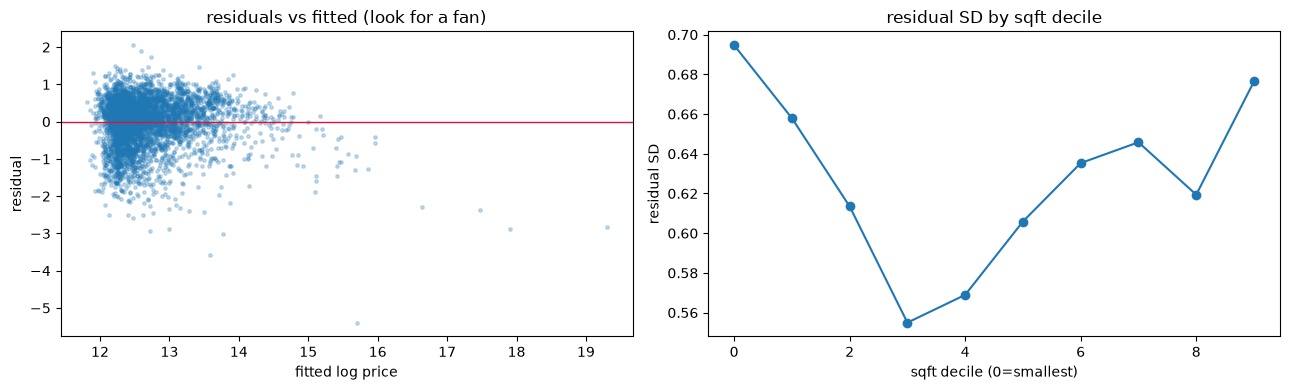

Breusch-Pagan p-value: 6.06e-38  (small => heteroskedastic)


In [60]:
from statsmodels.stats.diagnostic import het_breuschpagan

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# residual vs fitted — the textbook funnel view (trend removed)
fitted = res1.fittedvalues.to_numpy()
sr = np.random.default_rng(0).choice(len(fitted), min(5000, len(fitted)), replace=False)
ax[0].scatter(fitted[sr], resid[sr], s=6, alpha=0.25); ax[0].axhline(0, color="crimson", lw=1)
ax[0].set_title("residuals vs fitted (look for a fan)"); ax[0].set_xlabel("fitted log price"); ax[0].set_ylabel("residual")
# residual SD by sqft decile — the funnel as a curve
ax[1].plot(tbl.index, tbl["resid_sd"], "o-"); ax[1].set_title("residual SD by sqft decile")
ax[1].set_xlabel("sqft decile (0=smallest)"); ax[1].set_ylabel("residual SD")
plt.tight_layout(); plt.show()

# formal test: H0 = homoskedastic. Tiny p (it will be) = reject = heteroskedastic.
lm, lm_p, f, f_p = het_breuschpagan(resid, res1.model.exog)
print(f"Breusch-Pagan p-value: {lm_p:.2e}  (small => heteroskedastic)")

#### Examining observations with smallest residuals (negative vals)

In [62]:
d["fitted"] = res1.fittedvalues.to_numpy()
d.nsmallest(10, "resid")[["sqft", "logp", "fitted", "resid"]]

,sqft,logp,fitted,resid
260382,5360.0,10.308953,15.701720,-5.392767
357661,5360.0,10.308953,15.701720,-5.392767
228060,9916.0,15.232577,19.279495,-4.046918
355528,3535.0,10.596635,14.268568,-3.671933
407739,2666.0,9.998798,13.586152,-3.587355
192962,1680.0,9.272282,12.811858,-3.539576
43152,1960.0,9.510445,13.031739,-3.521294
41745,3324.0,10.596635,14.102872,-3.506238
324566,1577.0,9.350102,12.730973,-3.380871
168912,7357.0,13.976779,17.269941,-3.293162


In [69]:
# Finding these in the model_df dataframe
cols = [
    "char_bldg_sf",
    "meta_sale_buyer_name",
    "meta_sale_seller_name",
    "loc_chicago_community_area_name",
    C.TARGET_RAW] + C.SV_REASON_COLS
model_df.loc[d.nsmallest(10, "resid").index, cols]

,char_bldg_sf,meta_sale_buyer_name,meta_sale_seller_name,loc_chicago_community_area_name,meta_sale_price,sv_outlier_reason1,sv_outlier_reason2,sv_outlier_reason3
260382,5360.0,"WARDELL AND KEITH PROPERTIES LLC, AN ILLINOIS ...",ERIC LEWIS,GREATER GRAND CROSSING,30000.0,Non-person sale,Statistical Anomaly,NaN
357661,5360.0,WARDELL AND KEITH PROPERTIES LLC,ERIC LEWIS,GREATER GRAND CROSSING,30000.0,Non-person sale,Statistical Anomaly,NaN
228060,9916.0,"CHICAGO TITLE LAND TRUST COMPANY, AS TRUSTEE U...","DOR TRUST DATED SEPTEMBER 28, 2001",KENWOOD,4125000.0,Non-person sale,Statistical Anomaly,NaN
355528,3535.0,DPA CHICAGO LLC,THE ESTATE OF DAISY GIVENS,ROSELAND,40000.0,Non-person sale,Statistical Anomaly,NaN
407739,2666.0,BMW PROPS LLC,JANICE A DOTSON,GREATER GRAND CROSSING,22000.0,Non-person sale,NaN,NaN
192962,1680.0,GEORGE W JOHNSON,FRANCES A WARD,WEST PULLMAN,10639.0,Low price,Low price per square foot,Statistical Anomaly
43152,1960.0,CARLOS MALAGON,NIKKI C FRANKLIN N/K/A NIKKI C. HARDEN,ENGLEWOOD,13500.0,Low price,Low price per square foot,NaN
41745,3324.0,ADRIANE GOODMAN,KEISHA KIDAN,GREATER GRAND CROSSING,40000.0,NaN,NaN,NaN
324566,1577.0,"ROCKNE HOLDINGS, LLC, A WYOMING LIMITED LIABIL...","5AIF SYCAMORE 2, LLC, A WYOMING LIMITED LIABIL...",NORTH LAWNDALE,11500.0,Non-person sale,Statistical Anomaly,NaN
168912,7357.0,CECILIA LYNN SETTLES,"JESSE M. MORRIS, AS TRUSTEE OF THE JMM LIVING ...",GRAND BOULEVARD,1175000.0,Non-person sale,Statistical Anomaly,NaN
